<a href="https://colab.research.google.com/github/mamunh9/Autonomous-Systems-Lab/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 07 — Stepwise SVM-Based Line Following from Synthetic Images

## Context

This lab applies Support Vector Machines (SVMs) to a simplified **line-following / lane-following** task.

We generate synthetic camera-like images:

- black background
- white guide line
- line may appear left, centered, or right
- later: line may also be curved and noisy

The target is a steering class:

- `LEFT`
- `STRAIGHT`
- `RIGHT`

The lab follows a **stepwise engineering approach**:

1. Start with a very simple feature representation.
2. Train and evaluate an SVM.
3. Analyze limitations.
4. Extend the feature set.
5. Improve validation and robustness testing.

This mirrors real engineering work: we begin with a simple baseline and only add complexity when necessary.

## Learning goals

After this lab, you should be able to:

1. Generate synthetic image data for a line-following task.
2. Build a minimal baseline feature set.
3. Understand why simple features can be insufficient.
4. Extend the feature set using interpretable image features.
5. Train and evaluate SVM models with preprocessing pipelines.
6. Use validation, grid search, ROC/AUC, and robustness testing.
7. Reflect on safety and robustness for ML-based technical systems.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_curve,
    auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

class_names = np.array(["LEFT", "STRAIGHT", "RIGHT"])

## 2. Synthetic image generation functions

In [7]:
def generate_line_image(
    img_size=64,
    command=1,
    curvature=0.0,
    thickness=3,
    noise_level=0.06,
    brightness=1.0,
    random_state=None
):
    """
    Generate one synthetic black-background image with a white line.

    command:
        0 = LEFT      -> line appears left at the bottom
        1 = STRAIGHT  -> line appears centered at the bottom
        2 = RIGHT     -> line appears right at the bottom
    """
    rng = np.random.default_rng(random_state)
    img = np.zeros((img_size, img_size), dtype=float)

    base_center = img_size // 2

    if command == 0:
        bottom_x = base_center - rng.integers(8, 18)
    elif command == 2:
        bottom_x = base_center + rng.integers(8, 18)
    else:
        bottom_x = base_center + rng.integers(-5, 6)

    slope = rng.normal(0.0, 0.10)

    ys = np.arange(img_size)
    y_norm = (img_size - 1 - ys) / (img_size - 1)

    xs = (
        bottom_x
        + slope * (ys - img_size / 2)
        + curvature * (y_norm ** 2) * img_size
    )

    for y_pos, x_pos in zip(ys, xs):
        x_int = int(round(x_pos))
        for dx in range(-thickness, thickness + 1):
            xx = x_int + dx
            if 0 <= xx < img_size:
                img[y_pos, xx] = brightness

    # Slight softening of the line
    img_shift_left = np.roll(img, 1, axis=1) * 0.35
    img_shift_right = np.roll(img, -1, axis=1) * 0.35
    img = np.clip(img + img_shift_left + img_shift_right, 0, 1)

    # Sensor noise
    img += rng.normal(0, noise_level, img.shape)
    img = np.clip(img, 0, 1)

    return img


def generate_dataset(
    n_samples=1200,
    img_size=64,
    noise_level=0.06,
    curved=True,
    random_state=42
):
    """
    Generate a dataset of synthetic line-following images.

    If curved=False, the data is simpler and mostly straight.
    If curved=True, line curvature is added.
    """
    rng = np.random.default_rng(random_state)
    images = []
    labels = []

    class_probs = [0.32, 0.36, 0.32]

    for _ in range(n_samples):
        command = rng.choice([0, 1, 2], p=class_probs)

        if curved:
            curvature = rng.normal(0.0, 0.10)
            if command == 0:
                curvature += rng.normal(-0.06, 0.04)
            elif command == 2:
                curvature += rng.normal(0.06, 0.04)
        else:
            curvature = rng.normal(0.0, 0.015)

        thickness = rng.integers(2, 5)
        brightness = rng.uniform(0.75, 1.0)

        img = generate_line_image(
            img_size=img_size,
            command=command,
            curvature=curvature,
            thickness=thickness,
            noise_level=noise_level,
            brightness=brightness,
            random_state=rng.integers(0, 1_000_000)
        )

        images.append(img)
        labels.append(command)

    return np.array(images), np.array(labels)


def extract_minimal_features(images):
    """
    Minimal baseline feature extraction.

    Only one idea is used:
    Where is the line at the bottom of the image?

    Features:
    - bottom_offset: normalized x-position of the white line in the lower image region
    - bottom_left_brightness
    - bottom_center_brightness
    - bottom_right_brightness

    This is intentionally simple.
    """
    rows = []
    eps = 1e-8

    for img in images:
        h, w = img.shape
        bottom = img[int(0.70*h):, :]

        third = w // 3
        left_region = bottom[:, :third]
        center_region = bottom[:, third:2*third]
        right_region = bottom[:, 2*third:]

        _, xx = np.mgrid[0:bottom.shape[0], 0:w]
        cx_bottom = (bottom * xx).sum() / (bottom.sum() + eps)
        bottom_offset = (cx_bottom - w/2) / (w/2)

        rows.append({
            "bottom_offset": bottom_offset,
            "bottom_left_brightness": left_region.mean(),
            "bottom_center_brightness": center_region.mean(),
            "bottom_right_brightness": right_region.mean(),
        })

    return pd.DataFrame(rows)


def extract_extended_features(images):
    """
    Extended feature extraction.

    This mimics a simple perception pipeline using multiple interpretable features:
    - center of line in lower image half
    - center of line in upper image half
    - bottom, middle, and top offsets
    - line direction
    - curvature proxy
    - brightness and left/right balance
    """
    feature_rows = []
    eps = 1e-8

    for img in images:
        h, w = img.shape
        yy, xx = np.mgrid[0:h, 0:w]

        total = img.sum() + eps

        cx = (img * xx).sum() / total
        cy = (img * yy).sum() / total

        lower = img[h//2:, :]
        upper = img[:h//2, :]

        yy_l, xx_l = np.mgrid[h//2:h, 0:w]
        yy_u, xx_u = np.mgrid[0:h//2, 0:w]

        lower_total = lower.sum() + eps
        upper_total = upper.sum() + eps

        cx_lower = (lower * xx_l).sum() / lower_total
        cx_upper = (upper * xx_u).sum() / upper_total

        bottom_region = img[int(0.75*h):, :]
        middle_region = img[int(0.45*h):int(0.65*h), :]
        top_region = img[:int(0.25*h), :]

        def region_cx(region):
            if region.sum() < eps:
                return w / 2
            _, region_xx = np.mgrid[0:region.shape[0], 0:region.shape[1]]
            return (region * region_xx).sum() / (region.sum() + eps)

        cx_bottom = region_cx(bottom_region)
        cx_middle = region_cx(middle_region)
        cx_top = region_cx(top_region)

        bottom_offset = (cx_bottom - w/2) / (w/2)
        middle_offset = (cx_middle - w/2) / (w/2)
        top_offset = (cx_top - w/2) / (w/2)

        line_direction = (cx_lower - cx_upper) / h

        expected_middle = 0.5 * (cx_bottom + cx_top)
        curvature_proxy = (cx_middle - expected_middle) / (w/2)

        white_ratio = (img > 0.5).mean()
        mean_brightness = img.mean()

        left_half = img[:, :w//2].sum()
        right_half = img[:, w//2:].sum()
        left_right_balance = (right_half - left_half) / (right_half + left_half + eps)

        lower_brightness = lower.mean()
        upper_brightness = upper.mean()

        feature_rows.append({
            "cx_global": (cx - w/2) / (w/2),
            "cy_global": cy / h,
            "cx_lower": (cx_lower - w/2) / (w/2),
            "cx_upper": (cx_upper - w/2) / (w/2),
            "bottom_offset": bottom_offset,
            "middle_offset": middle_offset,
            "top_offset": top_offset,
            "line_direction": line_direction,
            "curvature_proxy": curvature_proxy,
            "white_ratio": white_ratio,
            "mean_brightness": mean_brightness,
            "left_right_balance": left_right_balance,
            "lower_brightness": lower_brightness,
            "upper_brightness": upper_brightness,
        })

    return pd.DataFrame(feature_rows)

## 3. Generate and inspect synthetic images

In [8]:
# First dataset: includes straight and curved lines
images, y = generate_dataset(
    n_samples=1200,
    noise_level=0.06,
    curved=True,
    random_state=RANDOM_STATE
)

print("Images shape:", images.shape)
print("Class distribution:")
print(pd.Series(class_names[y]).value_counts())

Images shape: (1200, 64, 64)
Class distribution:
STRAIGHT    434
LEFT        399
RIGHT       367
Name: count, dtype: int64


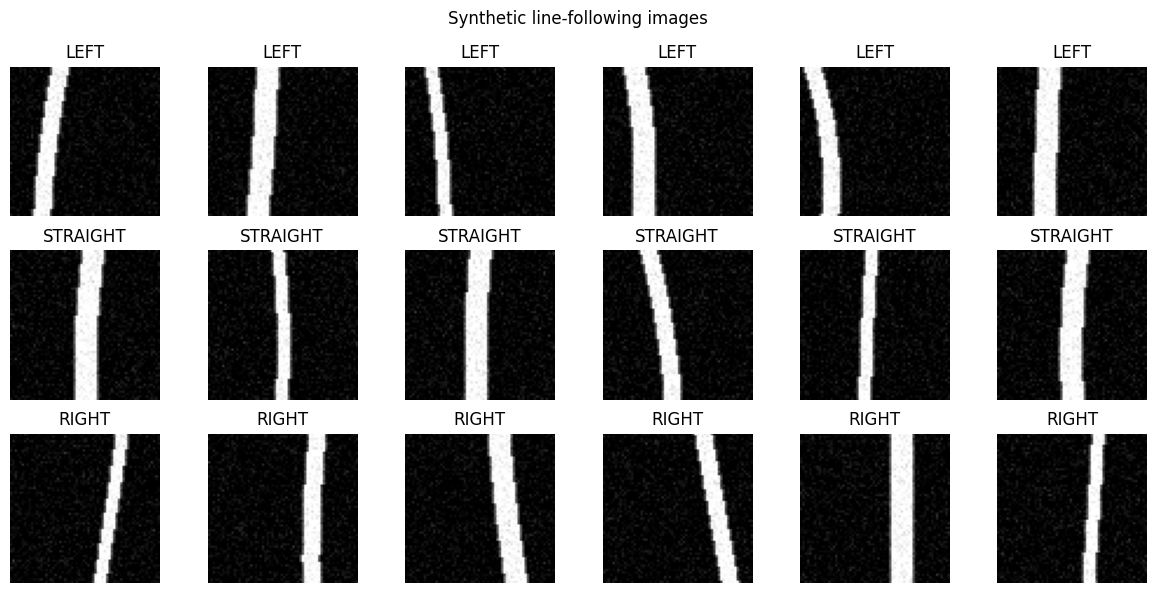

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for row, cls_idx in enumerate([0, 1, 2]):
    sample_indices = np.where(y == cls_idx)[0][:6]
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(images[idx], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        axes[row, col].set_title(class_names[cls_idx])
plt.suptitle("Synthetic line-following images")
plt.tight_layout()
plt.show()

### Exercise 1 — Image-based line-following data

1. Why is image-based synthetic data more realistic than directly generated abstract features?
2. Which aspects of real camera images are still missing?
3. Why are curved lines useful for this lab?

1. Image-based synthetic data is more realistic because it starts from image-like inputs.

2. Real camera images can  include lighting changes, shadows, blur, reflections, noise, different road textures, camera angle changes, lens distortion, and partial occlusions.

3. Curved lines are useful because they represent more realistic line-following situations than only straight lines. They help test whether the model can recognize when the vehicle should steer left, right, or continue straight.


## 4. Step 1: Minimal features

In the first step, we intentionally use only very simple features.

The main idea is:

> Look at the lower part of the image and estimate whether the line is left, centered, or right.

This corresponds to a very simple line-following strategy.

In [14]:
X_min = extract_minimal_features(images)

print("Minimal features:")
display(X_min.head())
display(X_min.describe())

Minimal features:


,bottom_offset,bottom_left_brightness,bottom_center_brightness,bottom_right_brightness
0,0.173492,0.025465,0.234845,0.061748
1,0.306560,0.023145,0.091647,0.291467
2,0.007918,0.021209,0.458812,0.027878
3,-0.017704,0.024110,0.275034,0.023642
4,0.364100,0.023318,0.059335,0.404733


,bottom_offset,bottom_left_brightness,bottom_center_brightness,bottom_right_brightness
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,-0.012708,0.094438,0.215481,0.101652
std,0.275325,0.122995,0.146931,0.129248
min,-0.549915,0.018319,0.020295,0.019289
25%,-0.267268,0.023259,0.065537,0.023530
50%,-0.018997,0.025125,0.234471,0.025123
75%,0.235990,0.139846,0.350981,0.170502
max,0.596839,0.464174,0.466028,0.443003


### Exercise 2 — Minimal feature interpretation

1. What does `bottom_offset` describe?
2. Why are bottom-left, bottom-center, and bottom-right brightness useful?
3. What information is missing in this minimal feature set?

1. bottom_offset describes how far the detected line is from the center of the image near the bottom.

2. Bottom-left, bottom-center, and bottom-right brightness values are useful because the bottom part of the image is closest to the vehicle. These brightness values help detect where the line appears in the area that is most important for immediate steering.

3. This minimal feature set misses a lot of visual information, such as the full line shape, curvature, thickness, noise, shadows, and information from the upper part of the image.


## 5. Train and evaluate the minimal-feature SVM

In [18]:
X_train_min, X_test_min, y_train, y_test, img_train, img_test = train_test_split(
    X_min, y, images,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train_min))
print("Test samples:", len(X_test_min))

Training samples: 900
Test samples: 300


Minimal-feature SVM accuracy: 0.93
Minimal-feature SVM macro F1: 0.9305911539602704

              precision    recall  f1-score   support

        LEFT       0.99      0.95      0.97       100
    STRAIGHT       0.85      0.97      0.91       108
       RIGHT       0.98      0.86      0.91        92

    accuracy                           0.93       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.94      0.93      0.93       300



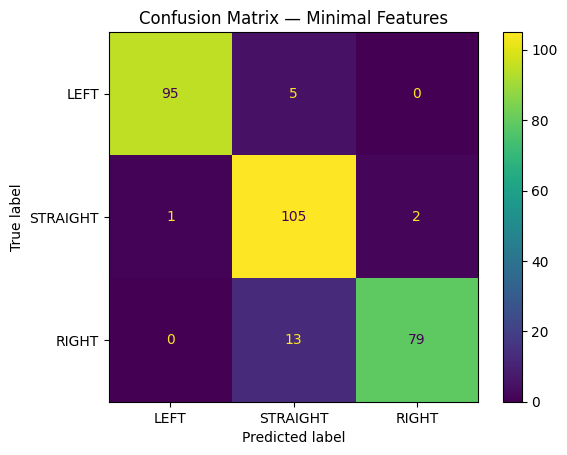

In [19]:
minimal_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

minimal_pipeline.fit(X_train_min, y_train)
y_pred_min = minimal_pipeline.predict(X_test_min)

print("Minimal-feature SVM accuracy:", accuracy_score(y_test, y_pred_min))
print("Minimal-feature SVM macro F1:", f1_score(y_test, y_pred_min, average="macro"))
print()
print(classification_report(y_test, y_pred_min, target_names=class_names))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_min),
    display_labels=class_names
).plot()
plt.title("Confusion Matrix — Minimal Features")
plt.show()

### Exercise 3 — Minimal model evaluation

1. How well does the minimal model perform?
2. Which classes are confused?
3. Why might the minimal features fail for curved lines?
4. Would this model be sufficient for a real technical system?


1. The minimal model performs reasonably on simple cases, but it is limited. It may classify clear left, center, and right examples correctly, but performance usually drops when the line is curved, noisy, or ambiguous.

2. The most likely confused classes are neighboring steering classes, such as left vs. center and right vs. center. Strong left and strong right are usually easier to distinguish, but small deviations near the center can be confused.

3. Minimal features can fail for curved lines because they only describe a small part of the image, especially near the bottom. A curved line may start in one position at the bottom but bend in another direction higher up, so the model misses important shape information.

4. No, this model would not be sufficient for a real technical system. It is useful for learning, but a real system would need better features, more realistic data, robustness testing, safety checks, and a controller that can handle uncertainty and errors.


## 6. Step 2: Extended interpretable features

Now we extend the feature set.

Instead of using only the line position near the bottom, we extract:

- line center in the lower image half
- line center in the upper image half
- bottom offset
- middle offset
- top offset
- line direction
- curvature proxy
- white pixel ratio
- mean brightness
- left/right brightness balance

This mimics a simple perception pipeline.

In [20]:
X_ext = extract_extended_features(images)

print("Extended features:")
display(X_ext.head())
display(X_ext.describe())

Extended features:


,cx_global,cy_global,cx_lower,cx_upper,bottom_offset,middle_offset,top_offset,line_direction,curvature_proxy,white_ratio,mean_brightness,left_right_balance,lower_brightness,upper_brightness
0,0.255282,0.493807,0.196452,0.314562,0.165304,0.248072,0.344507,-0.059055,-0.006834,0.078125,0.106347,0.769482,0.106754,0.105941
1,0.317234,0.493688,0.302280,0.332358,0.306419,0.304867,0.345359,-0.015039,-0.021022,0.109375,0.137217,0.827275,0.137995,0.136439
2,0.018312,0.492801,0.002718,0.033873,0.010190,-0.005575,0.052585,-0.015578,-0.036963,0.140625,0.167480,0.226167,0.167295,0.167664
3,-0.019374,0.490211,-0.013675,-0.024995,-0.017936,0.006702,-0.035769,0.005660,0.033555,0.078125,0.107010,-0.067538,0.106264,0.107757
4,0.292664,0.492318,0.342688,0.242493,0.369736,0.300196,0.217344,0.050098,0.006655,0.140869,0.166656,0.858863,0.166900,0.166412


,cx_global,cy_global,cx_lower,cx_upper,bottom_offset,middle_offset,top_offset,line_direction,curvature_proxy,white_ratio,mean_brightness,left_right_balance,lower_brightness,upper_brightness
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,-0.014852,0.492762,-0.013110,-0.016592,-0.012570,-0.014190,-0.017711,0.001741,0.000950,0.108993,0.136477,-0.001349,0.136648,0.136305
std,0.295489,0.004362,0.276585,0.324445,0.275687,0.285199,0.347861,0.058662,0.033849,0.025846,0.024625,0.723485,0.024636,0.024698
min,-0.579814,0.486802,-0.535212,-0.647096,-0.557067,-0.558321,-0.704451,-0.177904,-0.134178,0.068359,0.096335,-0.868789,0.103667,0.085839
25%,-0.281136,0.491422,-0.266890,-0.291699,-0.267051,-0.277552,-0.298588,-0.037950,-0.023573,0.078125,0.107744,-0.780450,0.107914,0.107742
50%,-0.014064,0.492235,-0.016665,-0.014164,-0.017632,-0.008951,-0.016051,0.002133,0.002122,0.109375,0.136684,0.021619,0.136805,0.136629
75%,0.259614,0.493103,0.245576,0.256972,0.230154,0.253161,0.268633,0.042045,0.025617,0.140625,0.165833,0.778550,0.165754,0.165836
max,0.572304,0.568689,0.552416,0.630315,0.611752,0.532248,0.668984,0.188435,0.123203,0.141357,0.169433,0.868471,0.169347,0.170169


### Exercise 4 — Extended feature interpretation

1. Why is `top_offset` useful in addition to `bottom_offset`?
2. What does `line_direction` describe?
3. Why can `curvature_proxy` help?
4. Why can brightness-related features matter?

 1. top_offset is useful because it describes where the line is farther ahead in the image. Together with `bottom_offset`, it helps show whether the line is straight or changing direction.

2. line_direction describes how the line moves from the bottom of the image to the top of the image. It can indicate whether the line is leaning left, leaning right, or staying mostly straight.

3. curvature_proxy can help because it gives the model information about how strongly the line bends. This is useful for distinguishing straight paths from curved paths and for predicting better steering directions.

4. Brightness-related features matter because the line is detected through pixel intensity. Changes in brightness can indicate where the line is located, but they can also be affected by shadows, lighting, noise, or faded markings.


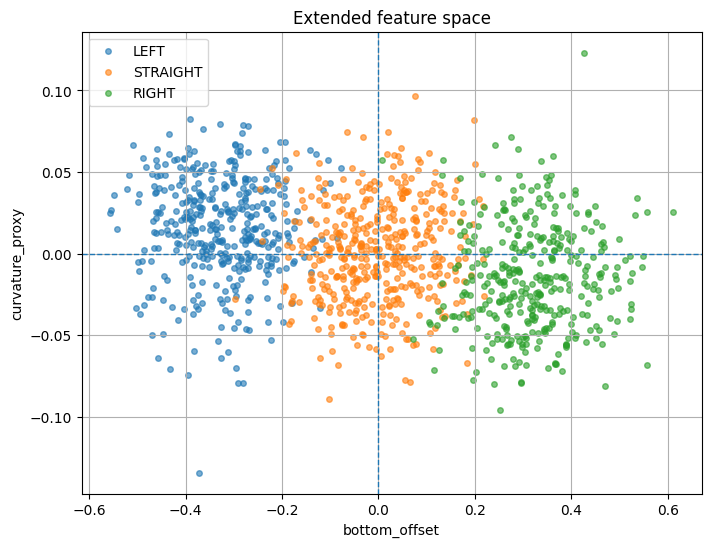

In [21]:
plt.figure(figsize=(8, 6))
for cls_idx, cls_name in enumerate(class_names):
    mask = y == cls_idx
    plt.scatter(
        X_ext.loc[mask, "bottom_offset"],
        X_ext.loc[mask, "curvature_proxy"],
        s=16,
        alpha=0.6,
        label=cls_name
    )
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("bottom_offset")
plt.ylabel("curvature_proxy")
plt.title("Extended feature space")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 5 — Feature-space analysis

1. Do the extended features separate the classes better?
2. Why is there still overlap?
3. What does overlap imply for the SVM margin?

 1. Yes, the extended features separate the classes better than the minimal features because they include more information about the line position, direction, curvature, and brightness. This gives the SVM more useful patterns for classification.

2. There is still overlap because some images can look similar even if they belong to different classes. For example, a slightly curved line and a nearly centered line may produce similar feature values. Noise, brightness variation, and limited feature extraction can also cause overlap.

3. Overlap means the SVM cannot create a perfect margin that separates all classes cleanly. Some samples will lie close to the decision boundary or on the wrong side of it, so the SVM must use a soft margin and accept some classification errors.


## 7. Train and evaluate the extended-feature SVM

In [23]:
X_train_ext, X_test_ext, _, _, _, _ = train_test_split(
    X_ext, y, images,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

Extended-feature SVM accuracy: 0.99
Extended-feature SVM macro F1: 0.9900934747872805

              precision    recall  f1-score   support

        LEFT       1.00      0.99      0.99       100
    STRAIGHT       0.98      0.99      0.99       108
       RIGHT       0.99      0.99      0.99        92

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



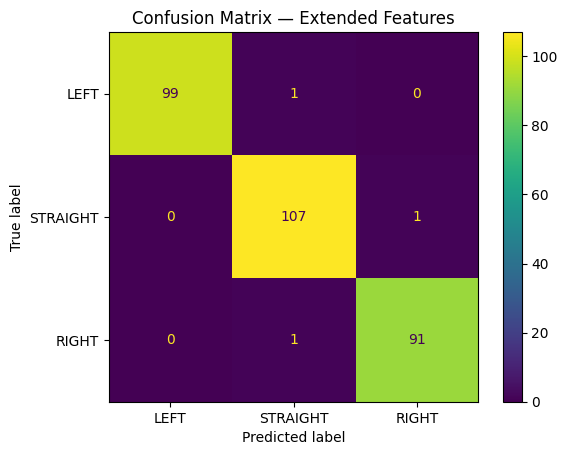

In [24]:
extended_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

extended_pipeline.fit(X_train_ext, y_train)
y_pred_ext = extended_pipeline.predict(X_test_ext)

print("Extended-feature SVM accuracy:", accuracy_score(y_test, y_pred_ext))
print("Extended-feature SVM macro F1:", f1_score(y_test, y_pred_ext, average="macro"))
print()
print(classification_report(y_test, y_pred_ext, target_names=class_names))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_ext),
    display_labels=class_names
).plot()
plt.title("Confusion Matrix — Extended Features")
plt.show()

### Exercise 6 — Minimal vs. extended model

1. Compare the minimal-feature and extended-feature models.
2. Which model is more suitable for curved lines?
3. Why should we begin with a baseline before using more features?

1. The extended-feature model performs better than the minimal-feature model because it uses more information from the image, such as top offset, direction, curvature, and brightness. The minimal model only uses simple bottom-region information, so it is more limited.

2. The extended-feature model is more suitable for curved lines because it can describe how the line changes from bottom to top and how strongly it curves. The minimal model may miss this because it mostly looks at the lower part of the image.

3. We should begin with a baseline because it gives us a simple reference point. Then we can check whether adding more features actually improves performance. A baseline also helps us understand the problem before making the model more complex.


## 8. Validation and hyperparameter tuning

In [25]:
cv_scores = cross_val_score(
    extended_pipeline,
    X_train_ext,
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("5-fold macro F1 scores:", cv_scores)
print("Mean macro F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

param_grid = {
    "svm__C": [0.1, 1, 10, 50],
    "svm__gamma": [0.01, 0.1, 1, "scale"]
}

grid = GridSearchCV(
    extended_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_ext, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation macro F1:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_ext)

print("\\nFinal test accuracy:", accuracy_score(y_test, y_pred_best))
print("Final test macro F1:", f1_score(y_test, y_pred_best, average="macro"))
print()
print(classification_report(y_test, y_pred_best, target_names=class_names))

5-fold macro F1 scores: [0.99465435 0.99441302 0.98260343 0.99465435 0.99439737]
Mean macro F1: 0.9921445037883092
Standard deviation: 0.004771838634154862
Best parameters: {'svm__C': 50, 'svm__gamma': 0.01}
Best cross-validation macro F1: 0.997768285075512
\nFinal test accuracy: 0.99
Final test macro F1: 0.9900934747872805

              precision    recall  f1-score   support

        LEFT       1.00      0.99      0.99       100
    STRAIGHT       0.98      0.99      0.99       108
       RIGHT       0.99      0.99      0.99        92

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



### Exercise 7 — Validation and tuning

1. Why do we use cross-validation?
2. Why is macro F1 useful here?
3. What does `C` control?
4. What does `gamma` control?
5. Why do we evaluate the final model on a separate test set?


1. We use cross-validation to test the model on several different train/validation splits. This gives a more reliable estimate of performance than using only one split and helps reduce the effect of random chance.

2. Macro F1 is useful because it gives equal importance to each class. This matters when some classes may be harder to detect or less frequent, because accuracy alone can hide poor performance on one class.

3. `C` controls the soft-margin trade-off. A small `C` allows more mistakes and creates a smoother boundary, while a large `C` tries harder to classify the training data correctly and may overfit.

4. `gamma` controls how local the influence of each training point is in the RBF kernel. A small `gamma` gives a smoother, broader decision boundary, while a large `gamma` creates a more complex and local boundary.

5. We evaluate the final model on a separate test set to estimate how well it performs on unseen data. The test set should not be used during tuning, otherwise the result may be too optimistic.


## 9. Error analysis: inspect misclassified images

Number of misclassified test images: 3


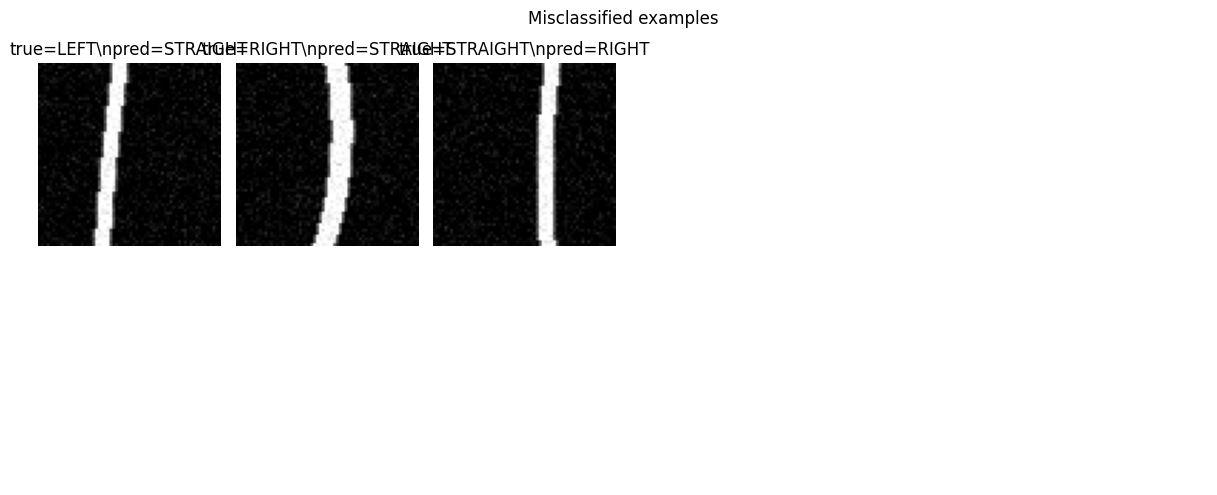

In [27]:
misclassified = np.where(y_pred_best != y_test)[0]
print("Number of misclassified test images:", len(misclassified))

n_show = min(12, len(misclassified))
if n_show > 0:
    fig, axes = plt.subplots(2, 6, figsize=(12, 5))
    axes = axes.ravel()
    for ax, local_idx in zip(axes, misclassified[:n_show]):
        ax.imshow(img_test[local_idx], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(
            f"true={class_names[y_test[local_idx]]}\\n"
            f"pred={class_names[y_pred_best[local_idx]]}"
        )
    for ax in axes[n_show:]:
        ax.axis("off")
    plt.suptitle("Misclassified examples")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples in this test split.")

### Exercise 8 — Error analysis

1. What do the misclassified images have in common?
2. Are some cases ambiguous even for humans?
3. Which additional features or preprocessing steps could help?

1. The misclassified images often have line positions or shapes that are close to the boundary between classes. For example, a line may be slightly left or right but still almost centered. Curved lines, noisy images, weak contrast, or unclear brightness patterns can also be misclassified.

2. Yes, some cases can be ambiguous even for humans. If the line is only slightly curved, partly visible, noisy, or close to the center, it may not be obvious whether the correct label should be left, center, or right.

3. Additional features could help, such as stronger curvature measurements, line angle, line thickness, contrast, and features from multiple image regions. Preprocessing steps like smoothing, thresholding, edge detection, perspective correction, and noise reduction could also improve the model.


## 10. ROC/AUC

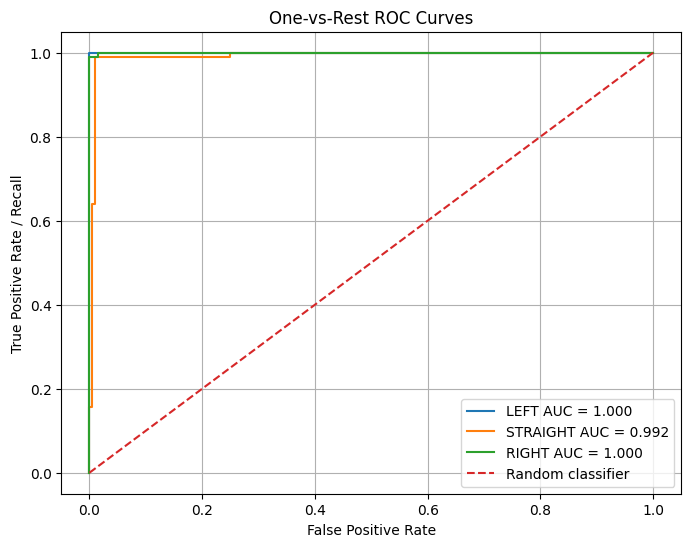

In [28]:
y_score = best_model.decision_function(X_test_ext)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
for i, cls_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls_name} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 9 — ROC/AUC

1. What does ROC stand for?
2. What does AUC stand for?
3. Why can ROC/AUC be useful in addition to accuracy?

1. ROC stands for Receiver Operating Characteristic. It is a curve that shows the relationship between the true positive rate and the false positive rate at different decision thresholds.

2. AUC stands for Area Under the Curve. It summarizes the ROC curve into one value. A higher AUC means the model separates the classes better.

3. ROC/AUC is useful in addition to accuracy because accuracy only evaluates performance at one decision threshold. ROC/AUC shows how well the model performs across many thresholds and is especially useful when class balance or error costs matter.


## 11. Robustness test: image noise

,noise_level,accuracy,macro_f1
0,0.00,0.990000,0.990093
1,0.03,0.993333,0.993445
2,0.06,0.980000,0.980217
3,0.10,0.950000,0.950651
4,0.15,0.863333,0.863820
5,0.25,0.716667,0.713102


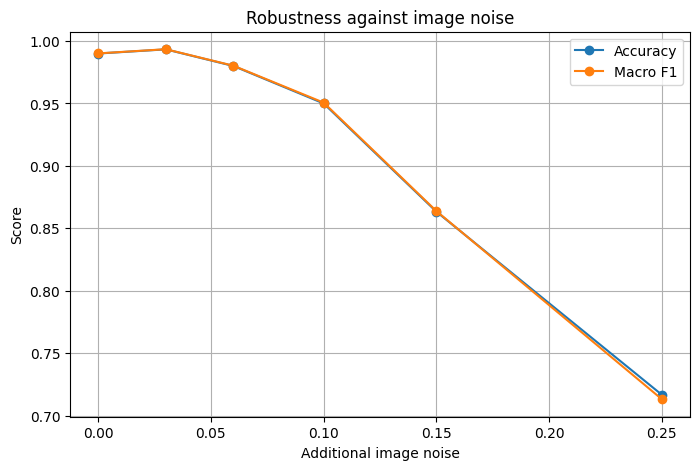

In [29]:
def evaluate_image_noise(model, base_images, y_true, noise_levels):
    results = []
    rng = np.random.default_rng(RANDOM_STATE)

    for noise in noise_levels:
        noisy_images = np.clip(base_images + rng.normal(0, noise, base_images.shape), 0, 1)
        X_noisy = extract_extended_features(noisy_images)
        y_pred_noisy = model.predict(X_noisy)

        results.append({
            "noise_level": noise,
            "accuracy": accuracy_score(y_true, y_pred_noisy),
            "macro_f1": f1_score(y_true, y_pred_noisy, average="macro")
        })

    return pd.DataFrame(results)

noise_results = evaluate_image_noise(
    best_model,
    img_test,
    y_test,
    noise_levels=[0.0, 0.03, 0.06, 0.10, 0.15, 0.25]
)

display(noise_results)

plt.figure(figsize=(8, 5))
plt.plot(noise_results["noise_level"], noise_results["accuracy"], marker="o", label="Accuracy")
plt.plot(noise_results["noise_level"], noise_results["macro_f1"], marker="o", label="Macro F1")
plt.xlabel("Additional image noise")
plt.ylabel("Score")
plt.title("Robustness against image noise")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 10 — Robustness

1. What happens when image noise increases?
2. Why is this relevant for camera-based systems?
3. How could robustness be improved?

 1. When image noise increases, the model usually becomes less accurate.
2. This is relevant for camera-based systems because real cameras often produce noisy or imperfect images.
3. Robustness could be improved by training with noisy and varied images, adding data augmentation, improving preprocessing with filtering or smoothing, using better feature extraction, and testing the model under different realistic conditions before deployment.

## 12. Dataset shift: changed line appearance

Shifted appearance accuracy: 0.8375
Shifted appearance macro F1: 0.8409854103524901

              precision    recall  f1-score   support

        LEFT       1.00      0.72      0.83       130
    STRAIGHT       0.70      1.00      0.82       153
       RIGHT       1.00      0.76      0.86       117

    accuracy                           0.84       400
   macro avg       0.90      0.83      0.84       400
weighted avg       0.89      0.84      0.84       400



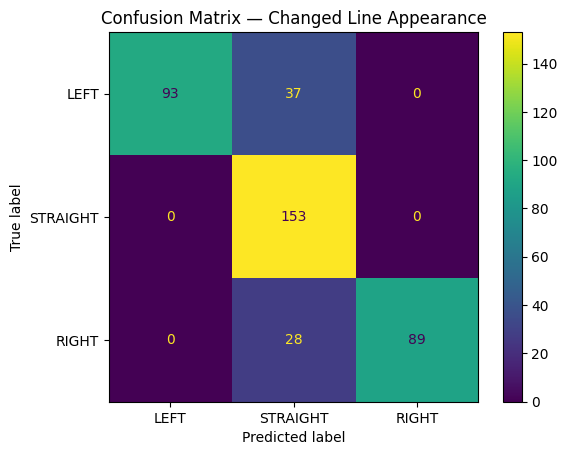

In [30]:
images_shifted, y_shifted = generate_dataset(
    n_samples=400,
    noise_level=0.16,
    curved=True,
    random_state=123
)

rng = np.random.default_rng(123)
images_shifted = np.clip(0.65 * images_shifted + rng.normal(0, 0.06, images_shifted.shape), 0, 1)

X_shifted = extract_extended_features(images_shifted)
y_shifted_pred = best_model.predict(X_shifted)

print("Shifted appearance accuracy:", accuracy_score(y_shifted, y_shifted_pred))
print("Shifted appearance macro F1:", f1_score(y_shifted, y_shifted_pred, average="macro"))
print()
print(classification_report(y_shifted, y_shifted_pred, target_names=class_names))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_shifted, y_shifted_pred),
    display_labels=class_names
).plot()
plt.title("Confusion Matrix — Changed Line Appearance")
plt.show()

### Exercise 11 — Dataset shift

1. Compare the shifted result to the original test result.
2. What changed in the input data?
3. Why is dataset shift dangerous?
4. What would you test before deployment?


1. The shifted result is worse than the original test result. The model performed better on the original test data because that data came from the same distribution as the training data. After shifting the input data, the model made more mistakes because the new data no longer matched what it learned during training.

2. The input data was changed by applying a shift to the feature values. This means the samples were moved away from their original positions. Even if the class labels stayed the same, the feature distribution changed.

3. Dataset shift is dangerous because a model can look accurate during testing but fail when real-world data changes. In deployment, sensor values, lighting, road conditions, noise, or hardware differences can make the input data different from the training data. This can reduce performance and create unsafe predictions.

4. Before deployment, I would test the model on noisy data, shifted data, scaled data, missing or corrupted sensor values, and data from different real-world conditions. I would also compare accuracy, recall, precision, confusion matrices, and false negatives to make sure the model is reliable and safe.


## 13. Final engineering reflection

Answer:

1. What is the complete pipeline from image to steering command?
2. Which parts are classical programming?
3. Which part is machine learning?
4. Why should such a classifier not directly control a steering actuator?
5. Where would this model be placed in the Operator–Controller architecture?

1. The complete pipeline starts with an input image from the camera. The image is preprocessed, for example cropped, resized, converted to grayscale, blurred, or thresholded. Useful features are then extracted from the image. The trained classifier predicts the driving situation, such as left, center, or right. This prediction is then converted into a steering decision, such as steer left, go straight, or steer right.

2. The classical programming parts are image loading, preprocessing, feature extraction, data handling, thresholding, visualization, and the rule that converts the predicted class into a steering command. These steps are written explicitly by the programmer.

3. The machine learning part is the trained classifier. It learns from labeled examples and predicts the class of a new image based on the extracted features.

4. Such a classifier should not directly control a steering actuator because it can make wrong predictions, especially with noise, unusual lighting, damaged lane markings, or dataset shift. A safety-critical actuator needs validation, supervision, fallback behavior, and control logic before any command is executed.

5. In the Operator-Controller architecture, this model would be placed in the Operator part. It interprets the camera image and suggests a high-level driving decision. The Controller would then check, filter, and convert that decision into safe low-level steering actuator commands.
